Scraping Data

In [126]:
!pip install google-play-scraper

In [127]:
from google_play_scraper import app
import pandas as pd
import numpy as np
from google_play_scraper import Sort, reviews

In [128]:
result, continuation_token = reviews(
    'com.kai.kaiticketing',  #
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=5000,
    filter_score_with=None
)
print(len(result))

df_kai = pd.DataFrame(np.array(result), columns=['review'])
df_kai = df_kai.join(pd.DataFrame(df_kai.pop('review').tolist()))

5000


In [129]:
df_kai.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ef2ed369-4501-4e3b-86a7-58114b8cfbe9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,suara pengumuman pemberitahuan kedatangan kere...,1,5,6.17.1,2026-04-11 10:36:02,None,NaT,6.17.1
1,56a16c0f-9ab3-4732-a6b0-a4b72e078808,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi bagus, tapi maximum booking 6x/hari s...",4,5,6.17.1,2026-03-27 01:45:49,None,NaT,6.17.1
2,6d3fea3d-0c57-45ba-9b51-850663eb553d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sering eror ya, tinggal bayar tiba tiba keluar...",1,5,6.17.0,2026-03-18 17:54:39,None,NaT,6.17.0
3,ef71e899-801c-4c95-99de-fef48feb8d1c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"asli ini versi paling buruk, sangat menggangu ...",1,8,6.17.1,2026-03-22 16:41:17,None,NaT,6.17.1
4,783a60e8-2465-4cc7-b05c-8962b6366233,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya sudah semakin bagus tapi sepertiny...,5,3,6.17.1,2026-04-05 13:03:55,None,NaT,6.17.1


In [130]:
new_df = df_kai[['userName', 'score','at', 'content']]
sorted_df = new_df.sort_values(by='at', ascending=False)
sorted_df.to_csv("Data ulasan Kai Access.csv", index = False)

Case Folding

In [131]:
import re

def cleaningulasan(content):
    ulasan = re.sub(r'@[A-Za-z0-9]+',' ', content)
    ulasan = re.sub(r'#[A-Za-z0-9]+',' ', ulasan)
    ulasan = re.sub(r"http\S+",' ', ulasan)
    ulasan = re.sub(r'[0-9]+',' ', ulasan)
    ulasan = re.sub(r"[-()\"#/@;:<>{}'+=~|.!?,_]", " ", ulasan)
    ulasan = ulasan.strip()
    return ulasan

def clearEmoji(content):
    return content.encode('ascii', 'ignore').decode('ascii')

def replaceTOM(content):
    pola = re.compile(r'(.)\1{2,}', re.DOTALL)
    return pola.sub(r'\1', content)

def casefoldingText(content):
    ulasan = content.lower()
    return ulasan

# Mendefinisikan DataFrame baru dengan kolom yang dipilih
new_df_copy = new_df.copy()

# Membersihkan konten menggunakan fungsi yang telah dibuat
new_df_copy['Cleaning'] = new_df_copy['content'].apply(cleaningulasan)
new_df_copy['HapusEmoji'] = new_df_copy['Cleaning'].apply(clearEmoji)
new_df_copy['3/Lebih'] = new_df_copy['HapusEmoji'].apply(replaceTOM)
new_df_copy['CaseFolding'] = new_df_copy['3/Lebih'].apply(casefoldingText)

# Mengurutkan DataFrame berdasarkan kolom 'at'
sorted_df = new_df_copy.sort_values(by='at', ascending=False)

# Menyimpan DataFrame yang telah diolah ke dalam file CSV
sorted_df.to_csv("Data ulasan Kai Access1.csv", index=False)

In [132]:
new_df_copy.head()

,userName,score,at,content,Cleaning,HapusEmoji,3/Lebih,CaseFolding
0,Pengguna Google,1,2026-04-11 10:36:02,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...
1,Pengguna Google,4,2026-03-27 01:45:49,"Aplikasi bagus, tapi maximum booking 6x/hari s...",Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,aplikasi bagus tapi maximum booking x hari s...
2,Pengguna Google,1,2026-03-18 17:54:39,"sering eror ya, tinggal bayar tiba tiba keluar...",sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...
3,Pengguna Google,1,2026-03-22 16:41:17,"asli ini versi paling buruk, sangat menggangu ...",asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...
4,Pengguna Google,5,2026-04-05 13:03:55,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,aplikasinya sudah semakin bagus tapi sepertiny...


Pelabelan Dataset

In [133]:
label = []
for index, row in new_df.iterrows():
  if row['score'] == 1 or row['score'] == 2:
    label.append('Negatif')
  elif row['score'] == 3:
    label.append('Netral')
  else:
    label.append('Positif')
new_df_copy['sentimen'] = label

In [134]:
new_df_copy.head()

,userName,score,at,content,Cleaning,HapusEmoji,3/Lebih,CaseFolding,sentimen
0,Pengguna Google,1,2026-04-11 10:36:02,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,Negatif
1,Pengguna Google,4,2026-03-27 01:45:49,"Aplikasi bagus, tapi maximum booking 6x/hari s...",Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,aplikasi bagus tapi maximum booking x hari s...,Positif
2,Pengguna Google,1,2026-03-18 17:54:39,"sering eror ya, tinggal bayar tiba tiba keluar...",sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,Negatif
3,Pengguna Google,1,2026-03-22 16:41:17,"asli ini versi paling buruk, sangat menggangu ...",asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,Negatif
4,Pengguna Google,5,2026-04-05 13:03:55,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,aplikasinya sudah semakin bagus tapi sepertiny...,Positif


In [135]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Add this line to download the missing resource
from nltk.tokenize import word_tokenize

def tokenizingText(content):
    ulasan = word_tokenize(content)
    return ulasan

# Menerapkan tokenizingText pada setiap elemen di kolom 'CaseFolding'
new_df_copy['Tokenizing'] = new_df_copy['CaseFolding'].apply(tokenizingText)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [136]:
new_df_copy.head()

,userName,score,at,content,Cleaning,HapusEmoji,3/Lebih,CaseFolding,sentimen,Tokenizing
0,Pengguna Google,1,2026-04-11 10:36:02,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,Negatif,"[suara, pengumuman, pemberitahuan, kedatangan,..."
1,Pengguna Google,4,2026-03-27 01:45:49,"Aplikasi bagus, tapi maximum booking 6x/hari s...",Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,aplikasi bagus tapi maximum booking x hari s...,Positif,"[aplikasi, bagus, tapi, maximum, booking, x, h..."
2,Pengguna Google,1,2026-03-18 17:54:39,"sering eror ya, tinggal bayar tiba tiba keluar...",sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,Negatif,"[sering, eror, ya, tinggal, bayar, tiba, tiba,..."
3,Pengguna Google,1,2026-03-22 16:41:17,"asli ini versi paling buruk, sangat menggangu ...",asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,Negatif,"[asli, ini, versi, paling, buruk, sangat, meng..."
4,Pengguna Google,5,2026-04-05 13:03:55,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,aplikasinya sudah semakin bagus tapi sepertiny...,Positif,"[aplikasinya, sudah, semakin, bagus, tapi, sep..."


In [137]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

daftar_stopword = stopwords.words('indonesian')
daftar_stopword.extend(["yg", "dg", "rt", "saya", "di", "dan", "yang", "nya", "aplikasi", "aja", "udah", "tp", "cb", "ya","gk", "gak", "ga",
                         "pa", "jd","banget", "coba", "sdh", "kai", "access", "sih", "kalo", "pas", "kali", "udh", "masuk", "tolong","stasiun", "muncul" ])
daftar_stopword = set(daftar_stopword)

def stopwordText(words):
    return [word for word in words if word not in daftar_stopword]

# Assuming 'new_df' contains the data and 'Tokenizing' column has the tokenized words
new_df_copy['WithoutStopwords'] = new_df_copy['Tokenizing'].apply(stopwordText)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [138]:
new_df_copy.head(10)

,userName,score,at,content,Cleaning,HapusEmoji,3/Lebih,CaseFolding,sentimen,Tokenizing,WithoutStopwords
0,Pengguna Google,1,2026-04-11 10:36:02,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,Negatif,"[suara, pengumuman, pemberitahuan, kedatangan,...","[suara, pengumuman, pemberitahuan, kedatangan,..."
1,Pengguna Google,4,2026-03-27 01:45:49,"Aplikasi bagus, tapi maximum booking 6x/hari s...",Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,aplikasi bagus tapi maximum booking x hari s...,Positif,"[aplikasi, bagus, tapi, maximum, booking, x, h...","[bagus, maximum, booking, x, mengganggu, booki..."
2,Pengguna Google,1,2026-03-18 17:54:39,"sering eror ya, tinggal bayar tiba tiba keluar...",sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,Negatif,"[sering, eror, ya, tinggal, bayar, tiba, tiba,...","[eror, tinggal, bayar, trs, dialihkan, tulisan..."
3,Pengguna Google,1,2026-03-22 16:41:17,"asli ini versi paling buruk, sangat menggangu ...",asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,Negatif,"[asli, ini, versi, paling, buruk, sangat, meng...","[asli, versi, buruk, menggangu, server, lemot,..."
4,Pengguna Google,5,2026-04-05 13:03:55,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,aplikasinya sudah semakin bagus tapi sepertiny...,Positif,"[aplikasinya, sudah, semakin, bagus, tapi, sep...","[aplikasinya, bagus, menu, batalkan, pesanan, ..."
5,Pengguna Google,4,2026-03-15 17:20:00,di waktu krusial tiba tiba jadwal kereta tidak...,di waktu krusial tiba tiba jadwal kereta tidak...,di waktu krusial tiba tiba jadwal kereta tidak...,di waktu krusial tiba tiba jadwal kereta tidak...,di waktu krusial tiba tiba jadwal kereta tidak...,Positif,"[di, waktu, krusial, tiba, tiba, jadwal, keret...","[krusial, jadwal, kereta, tersedia, war, enakn..."
6,Pengguna Google,4,2026-03-14 21:46:46,"aplikasi nya lumayan baguss, tapi pelayanan ny...",aplikasi nya lumayan baguss tapi pelayanan ny...,aplikasi nya lumayan baguss tapi pelayanan ny...,aplikasi nya lumayan baguss tapi pelayanan ny...,aplikasi nya lumayan baguss tapi pelayanan ny...,Positif,"[aplikasi, nya, lumayan, baguss, tapi, pelayan...","[lumayan, baguss, pelayanan, mengajukan, kompl..."
7,Pengguna Google,1,2026-03-21 17:21:17,harusnya aplikasi ini tidak cocok untuk mendap...,harusnya aplikasi ini tidak cocok untuk mendap...,harusnya aplikasi ini tidak cocok untuk mendap...,harusnya aplikasi ini tidak cocok untuk mendap...,harusnya aplikasi ini tidak cocok untuk mendap...,Negatif,"[harusnya, aplikasi, ini, tidak, cocok, untuk,...","[cocok, bintang, menggunakannya, login, lemot,..."
8,Pengguna Google,1,2026-03-21 22:10:55,Perbaiki bug nya !! Ketersediaan tiket tidak k...,Perbaiki bug nya Ketersediaan tiket tidak k...,Perbaiki bug nya Ketersediaan tiket tidak k...,Perbaiki bug nya Ketersediaan tiket tidak kons...,perbaiki bug nya ketersediaan tiket tidak kons...,Negatif,"[perbaiki, bug, nya, ketersediaan, tiket, tida...","[perbaiki, bug, ketersediaan, tiket, konsisten..."
9,Pengguna Google,2,2026-04-12 17:19:14,Aplikasinya sudah oke dan bagus sangat mudah t...,Aplikasinya sudah oke dan bagus sangat mudah t...,Aplikasinya sudah oke dan bagus sangat mudah t...,Aplikasinya sudah oke dan bagus sangat mudah t...,aplikasinya sudah oke dan bagus sangat mudah t...,Negati

In [139]:
!pip install Sastrawi
!pip install swifter
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import swifter

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmed_wrapper(term):
    return stemmer.stem(term)

term_dict = {}

for document in new_df_copy['WithoutStopwords']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    print(term,":" ,term_dict[term])

def stemming_text(tokens):
    return [stemmer.stem(word) for word in tokens]

new_df_copy['Stemming'] = new_df_copy['WithoutStopwords'].apply(stemming_text)

Streaming output truncated to the last 5000 lines.
mslh : mslh
maunya : mau
sign : sign
sever : sever
accesnya : accesnya
impian : impi
merasakan : rasa
betulin : betulin
pakailah : pakai
kebijakannya : bijak
diuji : uji
launching : launching
utamakan : utama
turunkan : turun
thnks : thnks
tros : tros
menuhin : menuhin
gbisa : gbisa
mempersusah : susah
jeleek : jeleek
ditarik : tarik
rening : rening
dibelanjakan : belanja
belanjakan : belanja
mengendap : endap
alami : alami
malu : malu
maluin : maluin
try : try
again : again
later : later
pict : pict
inet : inet
mengganti : ganti
diteliti : teliti
dirasakan : rasa
qa : qa
semangat : semangat
penampilan : tampil
berantakan : beranta
cenderung : cenderung
ketimbang : ketimbang
kekacauan : kacau
ludes : ludes
lomba : lomba
cepetan : cepetan
sportif : sportif
kaum : kaum
retail : retail
diedit : edit
tuanya : tua
ready : ready
kantong : kantong
hny : hny
terbaca : baca
penyebab : sebab
sinkron : sinkron
trhadap : trhadap
pembayarn : pembay

In [140]:
new_df_copy.head()

,userName,score,at,content,Cleaning,HapusEmoji,3/Lebih,CaseFolding,sentimen,Tokenizing,WithoutStopwords,Stemming
0,Pengguna Google,1,2026-04-11 10:36:02,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,Negatif,"[suara, pengumuman, pemberitahuan, kedatangan,...","[suara, pengumuman, pemberitahuan, kedatangan,...","[suara, umum, pemberitahuan, datang, kereta, d..."
1,Pengguna Google,4,2026-03-27 01:45:49,"Aplikasi bagus, tapi maximum booking 6x/hari s...",Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,Aplikasi bagus tapi maximum booking x hari s...,aplikasi bagus tapi maximum booking x hari s...,Positif,"[aplikasi, bagus, tapi, maximum, booking, x, h...","[bagus, maximum, booking, x, mengganggu, booki...","[bagus, maximum, booking, x, ganggu, booking, ..."
2,Pengguna Google,1,2026-03-18 17:54:39,"sering eror ya, tinggal bayar tiba tiba keluar...",sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,Negatif,"[sering, eror, ya, tinggal, bayar, tiba, tiba,...","[eror, tinggal, bayar, trs, dialihkan, tulisan...","[eror, tinggal, bayar, trs, alih, tulis, seles..."
3,Pengguna Google,1,2026-03-22 16:41:17,"asli ini versi paling buruk, sangat menggangu ...",asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,Negatif,"[asli, ini, versi, paling, buruk, sangat, meng...","[asli, versi, buruk, menggangu, server, lemot,...","[asli, versi, buruk, menggangu, server, lot, p..."
4,Pengguna Google,5,2026-04-05 13:03:55,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,Aplikasinya sudah semakin bagus tapi sepertiny...,aplikasinya sudah semakin bagus tapi sepertiny...,Positif,"[aplikasinya, sudah, semakin, bagus, tapi, sep...","[aplikasinya, bagus, menu, batalkan, pesanan, ...","[aplikasi, bagus, menu, batal, pesan, kereta, ..."


In [141]:
# Jika new_df_copy adalah salinan yang ingin dimodifikasi
train_s0 = new_df_copy[new_df_copy['sentimen'] == 'Negatif'].copy()

# Mengisi nilai yang hilang pada kolom 'content' untuk baris yang terfilter
train_s0.loc[:, 'content'] = train_s0['content'].fillna("tidak ada komentar")

# Menampilkan beberapa baris pertama dari DataFrame yang telah dimodifikasi
train_s0.head()

,userName,score,at,content,Cleaning,HapusEmoji,3/Lebih,CaseFolding,sentimen,Tokenizing,WithoutStopwords,Stemming
0,Pengguna Google,1,2026-04-11 10:36:02,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,suara pengumuman pemberitahuan kedatangan kere...,Negatif,"[suara, pengumuman, pemberitahuan, kedatangan,...","[suara, pengumuman, pemberitahuan, kedatangan,...","[suara, umum, pemberitahuan, datang, kereta, d..."
2,Pengguna Google,1,2026-03-18 17:54:39,"sering eror ya, tinggal bayar tiba tiba keluar...",sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,sering eror ya tinggal bayar tiba tiba keluar...,Negatif,"[sering, eror, ya, tinggal, bayar, tiba, tiba,...","[eror, tinggal, bayar, trs, dialihkan, tulisan...","[eror, tinggal, bayar, trs, alih, tulis, seles..."
3,Pengguna Google,1,2026-03-22 16:41:17,"asli ini versi paling buruk, sangat menggangu ...",asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,asli ini versi paling buruk sangat menggangu ...,Negatif,"[asli, ini, versi, paling, buruk, sangat, meng...","[asli, versi, buruk, menggangu, server, lemot,...","[asli, versi, buruk, menggangu, server, lot, p..."
7,Pengguna Google,1,2026-03-21 17:21:17,harusnya aplikasi ini tidak cocok untuk mendap...,harusnya aplikasi ini tidak cocok untuk mendap...,harusnya aplikasi ini tidak cocok untuk mendap...,harusnya aplikasi ini tidak cocok untuk mendap...,harusnya aplikasi ini tidak cocok untuk mendap...,Negatif,"[harusnya, aplikasi, ini, tidak, cocok, untuk,...","[cocok, bintang, menggunakannya, login, lemot,...","[cocok, bintang, guna, login, lot, failed, dat..."
8,Pengguna Google,1,2026-03-21 22:10:55,Perbaiki bug nya !! Ketersediaan tiket tidak k...,Perbaiki bug nya Ketersediaan tiket tidak k...,Perbaiki bug nya Ketersediaan tiket tidak k...,Perbaiki bug nya Ketersediaan tiket tidak kons...,perbaiki bug nya ketersediaan tiket tidak kons...,Negatif,"[perbaiki, bug, nya, ketersediaan, tiket, tida...","[perbaiki, bug, ketersediaan, tiket, konsisten...","[baik, bug, sedia, tiket, konsisten, stabil, c..."


In [142]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

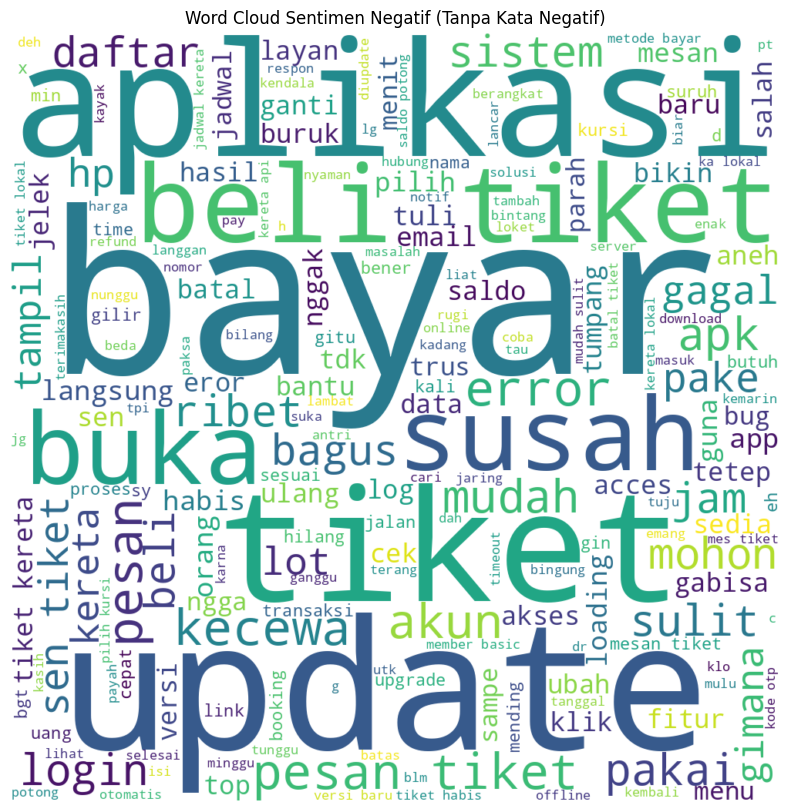

In [143]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Filter data sentimen negatif
train_negative = new_df_copy[new_df_copy['sentimen'] == 'Negatif'].copy()

# 2. Daftar kata negatif yang mau DIHAPUS
kata_negatif = ["baik"
]

# 3. Ambil kata selain kata negatif
filtered_tokens = [
    word
    for tokens in train_negative['Stemming']
    for word in tokens
    if word not in kata_negatif
]

# 4. Gabungkan jadi string
all_text_negative = ' '.join(filtered_tokens)

# 5. Generate WordCloud
wordcloud_negative = WordCloud(
    width=1000,
    height=1000,
    background_color='white',
).generate(all_text_negative)

# 6. Plot
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Negatif (Tanpa Kata Negatif)")
plt.show()

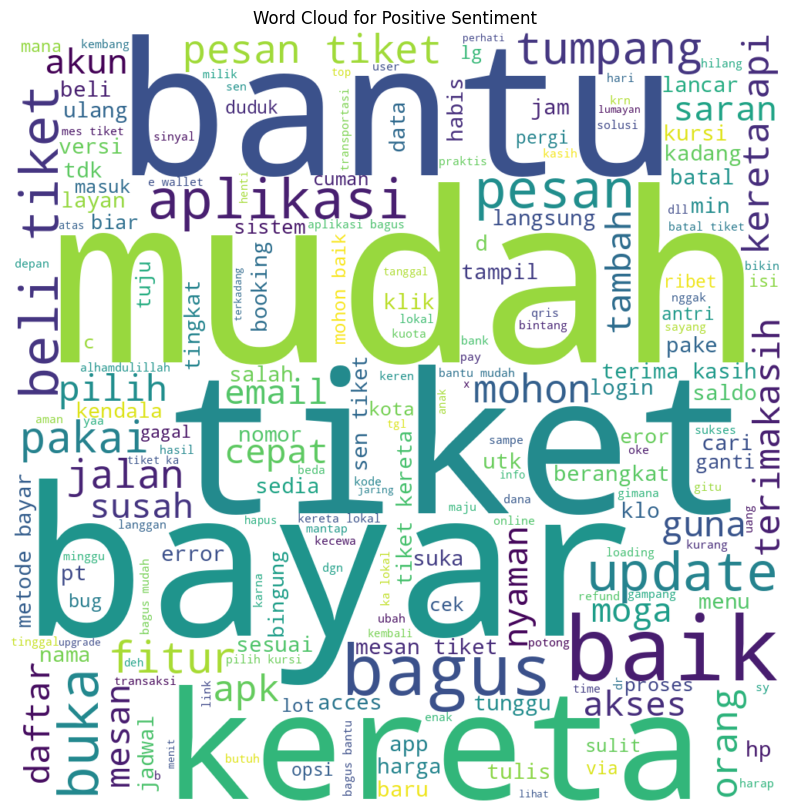

In [144]:
# Filter for positive sentiments
train_positive = new_df_copy[new_df_copy['sentimen'] == 'Positif'].copy()

# Combine all stemmed words into a single string for positive sentiments
all_stemmed_text_positive = ' '.join([' '.join(tokens) for tokens in train_positive['Stemming']])

# Generate WordCloud
wordcloud_positive = WordCloud(
    width=1000,
    height=1000,
    background_color='white',
).generate(all_stemmed_text_positive)

# Plot the WordCloud
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.margins(x=0, y=0)
plt.title("Word Cloud for Positive Sentiment")
plt.show()

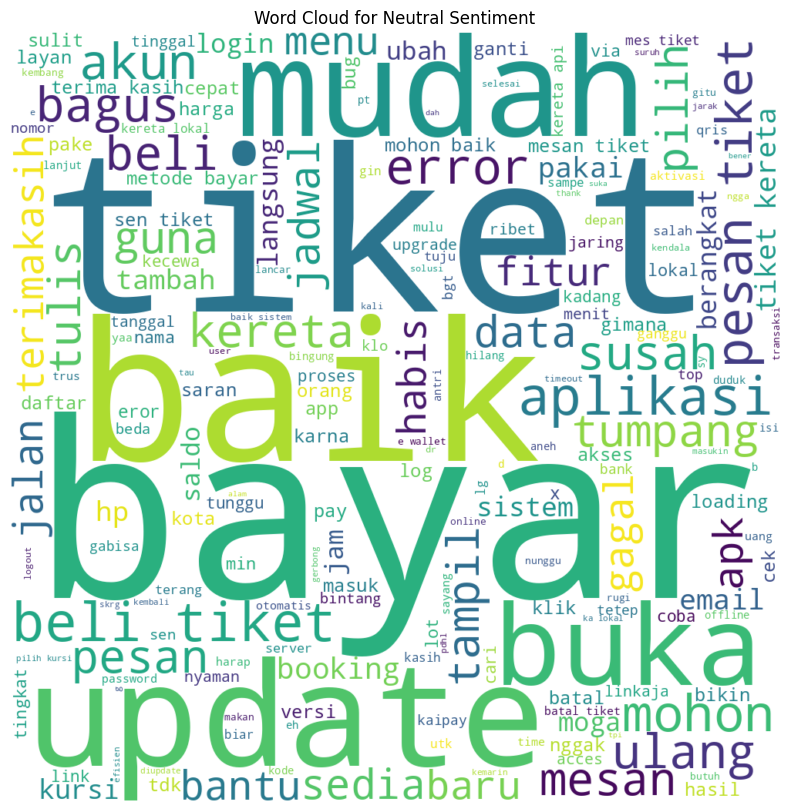

In [145]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter for neutral sentiments
train_s1 = new_df_copy[new_df_copy['sentimen'] == 'Netral'].copy()

# Combine all stemmed words into a single string for neutral sentiments
all_stemmed_text_neutral = ' '.join([' '.join(tokens) for tokens in train_s1['Stemming']])

# Generate WordCloud
wordcloud_neutral = WordCloud(
    width=1000,
    height=1000,
    background_color='white',
).generate(all_stemmed_text_neutral)

# Plot the WordCloud
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.axis('off')
plt.margins(x=0, y=0)
plt.title("Word Cloud for Neutral Sentiment")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

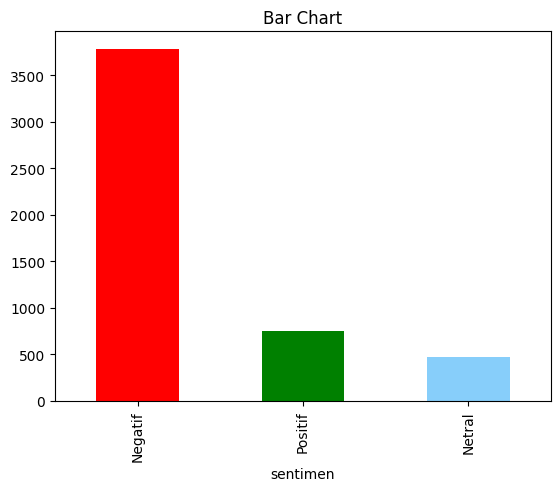

In [146]:
sentimen_data = pd.value_counts(new_df_copy['sentimen'], sort=True)
sentimen_data.plot(kind='bar', color=['red', 'green', 'lightskyblue'])
plt.title("Bar Chart")
plt.show

FastText dan klasifikasi dengan SVM dan random Vores

In [285]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer

# Create X_tfidf from the entire dataset's stemmed text
full_text = [' '.join(tokens) for tokens in new_df_copy['Stemming']]
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(full_text)

# Correctly refer to the sentiment column from new_df_copy
y_labels = new_df_copy['sentimen']

x_train, x_test, y_train, y_test = train_test_split(X_tfidf, y_labels, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((4000, 6821), (1000, 6821))

In [286]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Pastikan new_df berisi kolom 'Stemming' dan 'sentimen'
X = new_df_copy['Stemming']
Y = new_df_copy['sentimen']

# Misalkan x_train dan x_test adalah list token yang ingin digabungkan kembali menjadi teks
x_text = [' '.join(tokens) for tokens in X]

# Sekarang x_text berisi teks yang bisa digunakan untuk fit_transform
x_train, x_test, y_train, y_test = train_test_split(x_text, Y, test_size=0.2)

vectorizer = TfidfVectorizer()
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

Encoder = LabelEncoder()
y_train = Encoder.fit_transform(y_train)
y_test = Encoder.transform(y_test)

In [287]:
# Hitung total kemunculan setiap kata di semua dokumen
word_freq = x_train.sum(axis=0)

# Dapatkan indeks dari fitur kata pada vektorisasi
feature_names = vectorizer.get_feature_names_out()

# Buat daftar kata beserta jumlah kemunculannya
word_freq_list = [(word, word_freq[0, idx]) for word, idx in zip(feature_names, range(len(feature_names)))]

# Urutkan berdasarkan jumlah kemunculan kata
word_freq_list = sorted(word_freq_list, key=lambda x: x[1], reverse=True)

# Tampilkan beberapa kata beserta jumlah kemunculannya
num_words_to_display = 10  # Ganti dengan jumlah kata yang ingin ditampilkan
for word, freq in word_freq_list[:num_words_to_display]:
    print(f"Kata: {word}, Kemunculan: {freq}")

Kata: tiket, Kemunculan: 227.19606823278437
Kata: bayar, Kemunculan: 166.01029231484694
Kata: baik, Kemunculan: 119.10820916888342
Kata: kereta, Kemunculan: 109.97320297267066
Kata: pesan, Kemunculan: 107.4993357901684
Kata: beli, Kemunculan: 100.72714339054795
Kata: mudah, Kemunculan: 96.79055156855514
Kata: update, Kemunculan: 95.57087914339395
Kata: aplikasi, Kemunculan: 86.86709021396379
Kata: daftar, Kemunculan: 81.74271977185518


In [283]:
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

# Model
model = svm.SVC(kernel='linear', C=1, probability=True)

# Training
model.fit(x_train, y_train)

# Prediksi
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba = model.predict_proba(x_test)

roc = roc_auc_score(y_test_bin, y_pred_proba, average='macro')
print("ROC AUC:", roc)

cv_scores = cross_val_score(model, X_tfidf, Encoder.transform(y_labels), cv=5, scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Accuracy: 0.805
              precision    recall  f1-score   support

           0       0.80      0.99      0.89       758
           1       0.00      0.00      0.00        98
           2       0.83      0.37      0.51       144

    accuracy                           0.81      1000
   macro avg       0.54      0.45      0.47      1000
weighted avg       0.73      0.81      0.75      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ROC AUC: 0.7351106107843232
CV Scores: [0.793 0.813 0.806 0.79  0.792]
Mean CV Accuracy: 0.7988


In [288]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

# Ensure the vectorizer from the last TF-IDF step is used for full data transformation
# This assumes `vectorizer` and `Encoder` are available from previous cells (e.g., ohjcBmu2SCSb)
# and that `x_text` and `Y` are the full preprocessed text and labels.
full_text_transformed = vectorizer.transform([' '.join(tokens) for tokens in X])
full_labels_encoded = Encoder.transform(Y)

model_rf = RandomForestClassifier(
    n_estimators=500,        # lebih banyak pohon
    max_depth=None,          # biarkan dalam
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',     # penting!
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Training
model_rf.fit(x_train, y_train)

# Prediksi
y_pred_rf = model_rf.predict(x_test)

# Evaluasi
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba_rf = model_rf.predict_proba(x_test) # Use model_rf here

roc_rf = roc_auc_score(y_test_bin, y_pred_proba_rf, average='macro') # Use roc_rf
print("ROC AUC Random Forest:", roc_rf)

cv_scores_rf = cross_val_score(model_rf, full_text_transformed, full_labels_encoded, cv=5, scoring='accuracy') # Use model_rf and consistent full data

print("CV Scores Random Forest:", cv_scores_rf)
print("Mean CV Accuracy Random Forest:", cv_scores_rf.mean())

Accuracy Random Forest: 0.813
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       775
           1       0.00      0.00      0.00        81
           2       0.83      0.33      0.48       144

    accuracy                           0.81      1000
   macro avg       0.55      0.44      0.46      1000
weighted avg       0.75      0.81      0.76      1000

ROC AUC Random Forest: 0.7296725796136455
CV Scores Random Forest: [0.772 0.803 0.8   0.786 0.781]
Mean CV Accuracy Random Forest: 0.7884


In [289]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(x_train, y_train)
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba = model.predict_proba(x_test)

roc = roc_auc_score(y_test_bin, y_pred_proba, average='macro')
print("ROC AUC:", roc)

cv_scores = cross_val_score(model, X_tfidf, Encoder.transform(y_labels), cv=5, scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Accuracy: 0.776
              precision    recall  f1-score   support

           0       0.78      1.00      0.87       775
           1       0.00      0.00      0.00        81
           2       1.00      0.01      0.01       144

    accuracy                           0.78      1000
   macro avg       0.59      0.34      0.30      1000
weighted avg       0.75      0.78      0.68      1000

ROC AUC: 0.7341823752840644
CV Scores: [0.757 0.756 0.757 0.757 0.757]
Mean CV Accuracy: 0.7568


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [290]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

# Gaussian Naive Bayes requires dense input, convert if x_train/x_test are sparse
model_gnb = GaussianNB()
model_gnb.fit(x_train.toarray(), y_train)

y_pred_gnb = model_gnb.predict(x_test.toarray())

print("Accuracy Gaussian Naive Bayes:", accuracy_score(y_test, y_pred_gnb))
print(classification_report(y_test, y_pred_gnb))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba_gnb = model_gnb.predict_proba(x_test.toarray()) # Use model_gnb and convert x_test to dense

roc = roc_auc_score(y_test_bin, y_pred_proba_gnb, average='macro') # Use y_pred_proba_gnb
print("ROC AUC:", roc)

cv_scores = cross_val_score(model_gnb, X_tfidf.toarray(), Encoder.transform(y_labels), cv=5, scoring='accuracy') # Use model_gnb and X_tfidf.toarray()

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Accuracy Gaussian Naive Bayes: 0.558
              precision    recall  f1-score   support

           0       0.83      0.65      0.73       775
           1       0.09      0.28      0.14        81
           2       0.23      0.23      0.23       144

    accuracy                           0.56      1000
   macro avg       0.38      0.39      0.37      1000
weighted avg       0.68      0.56      0.61      1000

ROC AUC: 0.5548080874739892
CV Scores: [0.485 0.535 0.564 0.546 0.572]
Mean CV Accuracy: 0.5404


smote

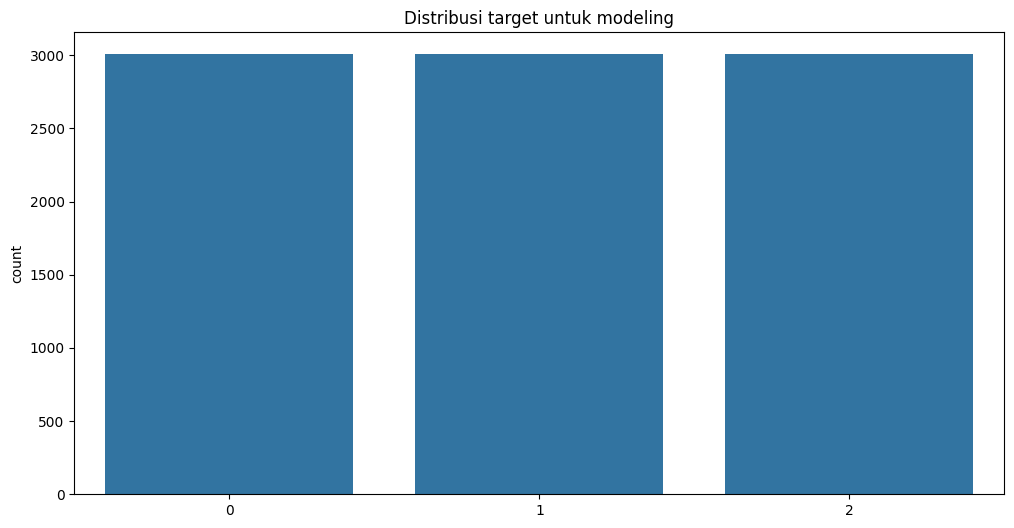

In [291]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

plt.figure(figsize=(12, 6))
sns.countplot(x=y_train)
plt.title('Distribusi target untuk modeling')
plt.show()

In [297]:
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

# Model
model = svm.SVC(kernel='linear', C=1, probability=True)

# Training
model.fit(x_train, y_train)

# Prediksi
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba = model.predict_proba(x_test)

roc = roc_auc_score(y_test_bin, y_pred_proba, average='macro')
print("ROC AUC:", roc)

cv_scores = cross_val_score(model, X_tfidf, Encoder.transform(y_labels), cv=5, scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Accuracy: 0.696
              precision    recall  f1-score   support

           0       0.84      0.79      0.82       775
           1       0.06      0.09      0.07        81
           2       0.46      0.51      0.48       144

    accuracy                           0.70      1000
   macro avg       0.46      0.46      0.46      1000
weighted avg       0.73      0.70      0.71      1000

ROC AUC: 0.7199513622615349
CV Scores: [0.793 0.813 0.806 0.79  0.792]
Mean CV Accuracy: 0.7988


In [293]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

# Ensure the vectorizer from the last TF-IDF step is used for full data transformation
# This assumes `vectorizer` and `Encoder` are available from previous cells (e.g., ohjcBmu2SCSb)
# and that `x_text` and `Y` are the full preprocessed text and labels.
full_text_transformed = vectorizer.transform([' '.join(tokens) for tokens in X])
full_labels_encoded = Encoder.transform(Y)

model_rf = RandomForestClassifier(
    n_estimators=500,        # lebih banyak pohon
    max_depth=None,          # biarkan dalam
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',     # penting!
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Training
model_rf.fit(x_train, y_train)

# Prediksi
y_pred_rf = model_rf.predict(x_test)

# Evaluasi
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba_rf = model_rf.predict_proba(x_test) # Use model_rf here

roc_rf = roc_auc_score(y_test_bin, y_pred_proba_rf, average='macro') # Use roc_rf
print("ROC AUC Random Forest:", roc_rf)

cv_scores_rf = cross_val_score(model_rf, full_text_transformed, full_labels_encoded, cv=5, scoring='accuracy') # Use model_rf and consistent full data

print("CV Scores Random Forest:", cv_scores_rf)
print("Mean CV Accuracy Random Forest:", cv_scores_rf.mean())

Accuracy Random Forest: 0.816
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       775
           1       0.00      0.00      0.00        81
           2       0.69      0.46      0.55       144

    accuracy                           0.82      1000
   macro avg       0.51      0.48      0.48      1000
weighted avg       0.74      0.82      0.77      1000

ROC AUC Random Forest: 0.725086775958833
CV Scores Random Forest: [0.772 0.803 0.8   0.786 0.781]
Mean CV Accuracy Random Forest: 0.7884


In [294]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(x_train, y_train)
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba = model.predict_proba(x_test)

roc = roc_auc_score(y_test_bin, y_pred_proba, average='macro')
print("ROC AUC:", roc)

cv_scores = cross_val_score(model, X_tfidf, Encoder.transform(y_labels), cv=5, scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Accuracy: 0.675
              precision    recall  f1-score   support

           0       0.88      0.74      0.81       775
           1       0.10      0.23      0.14        81
           2       0.54      0.57      0.55       144

    accuracy                           0.68      1000
   macro avg       0.51      0.51      0.50      1000
weighted avg       0.77      0.68      0.71      1000

ROC AUC: 0.7302223477411629
CV Scores: [0.757 0.756 0.757 0.757 0.757]
Mean CV Accuracy: 0.7568


In [295]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

# Gaussian Naive Bayes requires dense input, convert if x_train/x_test are sparse
model_gnb = GaussianNB()
model_gnb.fit(x_train.toarray(), y_train)

y_pred_gnb = model_gnb.predict(x_test.toarray())

print("Accuracy Gaussian Naive Bayes:", accuracy_score(y_test, y_pred_gnb))
print(classification_report(y_test, y_pred_gnb))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba_gnb = model_gnb.predict_proba(x_test.toarray()) # Use model_gnb and convert x_test to dense

roc = roc_auc_score(y_test_bin, y_pred_proba_gnb, average='macro') # Use y_pred_proba_gnb
print("ROC AUC:", roc)

cv_scores = cross_val_score(model_gnb, X_tfidf.toarray(), Encoder.transform(y_labels), cv=5, scoring='accuracy') # Use model_gnb and X_tfidf.toarray()

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Accuracy Gaussian Naive Bayes: 0.559
              precision    recall  f1-score   support

           0       0.83      0.65      0.73       775
           1       0.09      0.28      0.14        81
           2       0.23      0.24      0.23       144

    accuracy                           0.56      1000
   macro avg       0.38      0.39      0.37      1000
weighted avg       0.68      0.56      0.61      1000

ROC AUC: 0.5567101403094686
CV Scores: [0.485 0.535 0.564 0.546 0.572]
Mean CV Accuracy: 0.5404


plot perbandingan

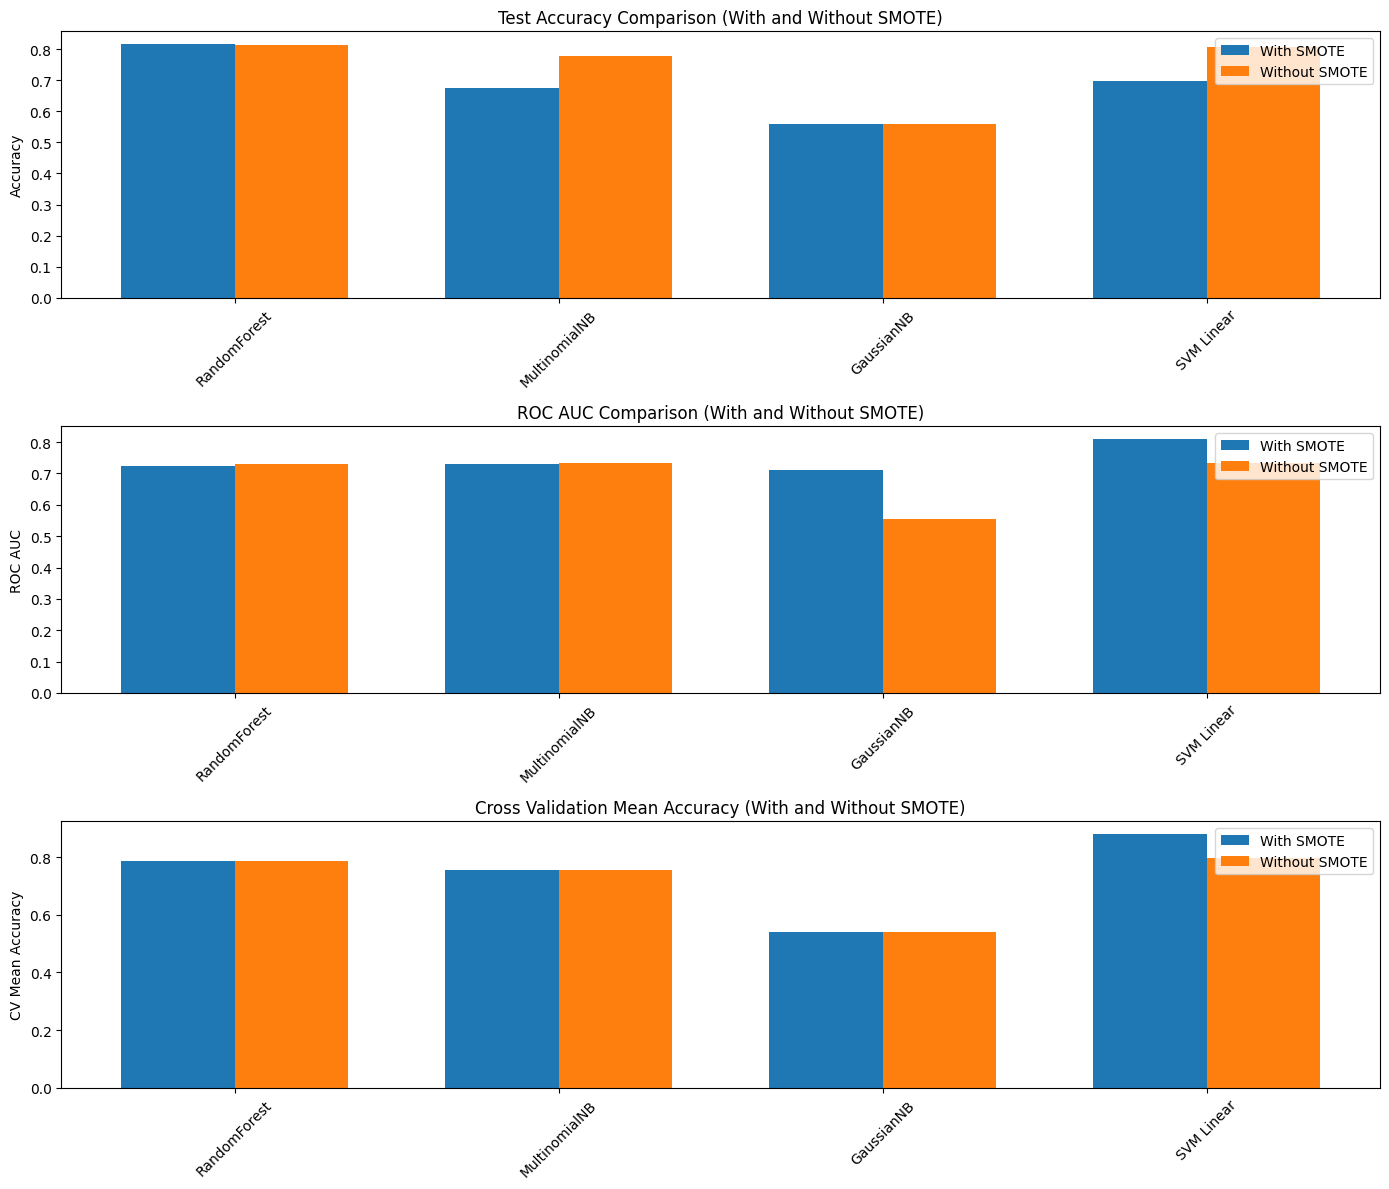

In [299]:
import matplotlib.pyplot as plt
import numpy as np

# Nama model
models = [
    'RandomForest', 'MultinomialNB', 'GaussianNB', 'SVM Linear'
]


# Accuracy
acc_smote = [0.816, 0.675, 0.559, 0.696]
acc_no_smote = [0.813, 0.776, 0.558, 0.805]


# ROC AUC
roc_smote = [0.725, 0.730, 0.711, 0.81]
roc_no_smote = [0.729, 0.734, 0.554, 0.735]

# Cross Validation
cv_smote = [0.788, 0.756, 0.540, 0.88]
cv_no_smote = [0.788, 0.756, 0.540, 0.798]


x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 🔹 1. Accuracy
axes[0].bar(x - width/2, acc_smote, width, label='With SMOTE')
axes[0].bar(x + width/2, acc_no_smote, width, label='Without SMOTE')
axes[0].set_title('Test Accuracy Comparison (With and Without SMOTE)')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45)
axes[0].legend()

# 🔹 2. ROC AUC
axes[1].bar(x - width/2, roc_smote, width, label='With SMOTE')
axes[1].bar(x + width/2, roc_no_smote, width, label='Without SMOTE')
axes[1].set_title('ROC AUC Comparison (With and Without SMOTE)')
axes[1].set_ylabel('ROC AUC')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45)
axes[1].legend()

# 🔹 3. Cross Validation
axes[2].bar(x - width/2, cv_smote, width, label='With SMOTE')
axes[2].bar(x + width/2, cv_no_smote, width, label='Without SMOTE')
axes[2].set_title('Cross Validation Mean Accuracy (With and Without SMOTE)')
axes[2].set_ylabel('CV Mean Accuracy')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45)
axes[2].legend()


plt.tight_layout()
plt.show()